# GenoPredict-AI — Analyse Exploratoire des Données (EDA)

Ce notebook illustre l'exploration statistique du jeu de données de
variants génétiques simulé (`data/variant_matrix.csv` et
`data/annotations.csv`) avant l'entraînement des modèles prédictifs.

**Objectifs :**
1. Charger et contrôler la qualité des données (module `src.ingestion`).
2. Explorer la distribution des variables cliniques et de la cible.
3. Visualiser les fréquences alléliques (MAF) et les tailles d'effet des variants.
4. Calculer et explorer le score de risque polygénique (PRS).

> ⚠️ Toutes les données utilisées ici sont **entièrement simulées**
> (voir `data/generate_synthetic_data.py`) à des fins de démonstration.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd

from src import features, ingestion

plt.rcParams["figure.figsize"] = (8, 4)
pd.set_option("display.max_columns", 20)

## 1. Génération et chargement des données

In [2]:
from generate_synthetic_data import generate_dataset

variant_df, annotations_df = generate_dataset(n_samples=600, n_variants=40, random_state=42)
variant_df.to_csv("variant_matrix.csv", index=False)
annotations_df.to_csv("annotations.csv", index=False)

variant_df = ingestion.load_variant_matrix("variant_matrix.csv")
annotations_df = ingestion.load_annotations("annotations.csv")
variant_df.head()

,sex,age,bmi,smoking_status,rs983584,rs7762164,rs6580257,rs4444896,rs4386850,rs8600118,...,rs2349663,rs1012145,rs5590388,rs8890108,rs731790,rs8597082,rs8293547,rs2839920,rs6353476,disease_status
sample_id,,,,,,,,,,,,,,,,,,,,,
SAMPLE_0001,M,19.1,25.1,current,0/0,0/0,0/1,0/1,0/0,0/0,...,0/0,0/0,0/1,0/1,0/1,0/0,0/0,0/0,0/0,1
SAMPLE_0002,F,71.9,22.7,current,0/1,0/0,1/1,0/1,0/0,0/0,...,0/0,0/1,1/1,0/1,0/0,0/0,0/0,0/0,0/0,1
SAMPLE_0003,M,44.7,30.9,never,0/1,0/0,0/0,1/1,0/0,0/0,...,0/0,0/0,0/0,0/0,0/0,0/1,0/1,0/0,0/0,0
SAMPLE_0004,M,42.3,25.5,former,0/1,0/0,1/1,0/1,1/1,0/0,...,0/0,0/0,./.,0/0,1/1,0/0,0/0,0/0,0/0,0
SAMPLE_0005,F,53.8,25.4,never,0/1,0/1,0/1,0/1,0/0,0/1,...,0/0,0/1,1/1,0/0,0/0,0/0,0/0,0/0,0/0,1


## 2. Contrôle qualité (QC)

In [3]:
clinical_cols = ["sex", "age", "bmi", "smoking_status"]
variant_cols = ingestion.identify_variant_columns(variant_df, clinical_cols)
clean_df, qc_report = ingestion.quality_control(
    variant_df, variant_cols, call_rate_threshold=0.90, maf_threshold=0.01
)
print(qc_report.summary())

=== Rapport de Contrôle Qualité (QC) ===
Échantillons : 600 -> 599 (1 exclus)
Variants     : 40 -> 40 (0 exclus)


## 3. Distribution des variables cliniques et de la cible

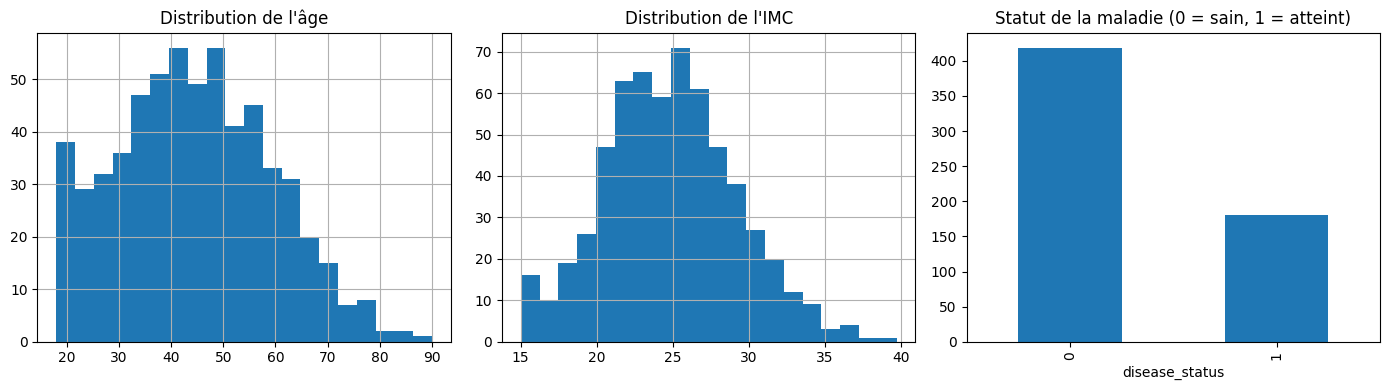

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
clean_df["age"].hist(ax=axes[0], bins=20)
axes[0].set_title("Distribution de l'âge")
clean_df["bmi"].hist(ax=axes[1], bins=20)
axes[1].set_title("Distribution de l'IMC")
clean_df["disease_status"].value_counts().sort_index().plot(kind="bar", ax=axes[2])
axes[2].set_title("Statut de la maladie (0 = sain, 1 = atteint)")
plt.tight_layout()
plt.show()

## 4. Fréquences alléliques (MAF) et scores CADD des variants

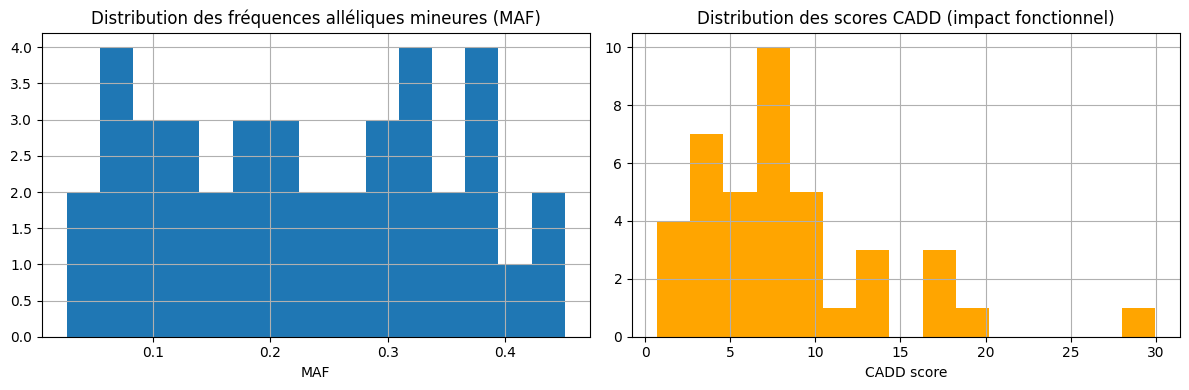

In [5]:
kept_variants = [c for c in variant_cols if c not in qc_report.dropped_variants]
maf_series = pd.Series(qc_report.variant_maf).loc[kept_variants]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
maf_series.hist(ax=axes[0], bins=15)
axes[0].set_title("Distribution des fréquences alléliques mineures (MAF)")
axes[0].set_xlabel("MAF")

annotations_df.loc[kept_variants, "cadd_score"].hist(ax=axes[1], bins=15, color="orange")
axes[1].set_title("Distribution des scores CADD (impact fonctionnel)")
axes[1].set_xlabel("CADD score")
plt.tight_layout()
plt.show()

## 5. Score de risque polygénique (PRS) et association avec la cible

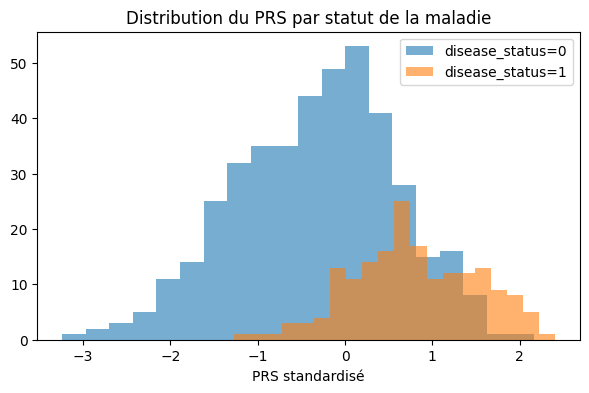

,count,mean,std,min,25%,50%,75%,max
disease_status,,,,,,,,
0,419.0,-0.338503,0.912871,-3.242251,-0.955051,-0.243336,0.289261,2.165533
1,180.0,0.787959,0.712605,-1.276925,0.232592,0.735252,1.350620,2.407013


In [6]:
prs = features.compute_polygenic_risk_score(
    clean_df[kept_variants], annotations_df["effect_size"]
)
prs_by_status = pd.DataFrame({"prs": prs, "disease_status": clean_df["disease_status"]})

fig, ax = plt.subplots(figsize=(7, 4))
for status, group in prs_by_status.groupby("disease_status"):
    ax.hist(group["prs"], bins=20, alpha=0.6, label=f"disease_status={status}")
ax.set_title("Distribution du PRS par statut de la maladie")
ax.set_xlabel("PRS standardisé")
ax.legend()
plt.show()

prs_by_status.groupby("disease_status")["prs"].describe()

## Conclusion

Le score de risque polygénique simulé montre une séparation visible
entre les groupes malades/non-malades, confirmant que le signal
génétique injecté est exploitable par les modèles prédictifs entraînés
dans `src/models.py`. L'étape suivante du pipeline (voir README) enchaîne
l'ingénierie des caractéristiques, l'entraînement avec validation croisée
et l'interprétabilité SHAP.